# 🍎 Asian Fruits Quality Grading & Detection
### Dataset: "A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research"
- **Mendeley Data DOI**: `10.17632/bz65dz2pbj.1`
- **Download Link**: `https://data.mendeley.com/public-api/zip/bz65dz2pbj/download/1`
- **Fruit Types (6)**: Apple, Banana, Burmese_grape, Mango, Papaya, Tomato
- **Quality Grades (3)**: 1st grade (Good/Fresh), 2nd grade (Medium), 3rd grade (Bad/Rotten)
- **Total Images**: 3,167 samples (224 × 224 resolution)
- **Classification Tasks Supported**:
  1. **Joint Fruit + Quality Classification (18 classes)**: `apple_good`, `apple_medium`, `banana_bad`, etc.
  2. **Quality-Only Grading (3 classes)**: `good`, `medium`, `bad`

In [1]:
import os
import sys
import glob
import zipfile
import urllib.request
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPool2D, Flatten, Dropout,
    GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset Configuration & Unpacking
Handles automated archive extraction, including nested archives like `Fruits Grade.zip`.

In [2]:
DATASET_URL = "https://data.mendeley.com/public-api/zip/bz65dz2pbj/download/1"
DATA_DIR = "./data/asian_fruits"
ZIP_PATH = "./data/asian_fruits_dataset.zip"

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.001

# Task Mode:
# - 'fruit_quality' : 18 classes (fruit x quality grade, e.g. apple_good, banana_bad)
# - 'quality_only'  : 3 classes (good, medium, bad across all fruits)
TASK_MODE = "fruit_quality"

FRUITS = ["apple", "banana", "burmese_grape", "burmese grape", "mango", "papaya", "tomato"]

# Map 1st grade, 2nd grade, 3rd grade to good, medium, bad
GRADE_MAP = {
    "1st grade": "good",
    "1st_grade": "good",
    "1st": "good",
    "first grade": "good",
    "good": "good",
    "2nd grade": "medium",
    "2nd_grade": "medium",
    "2nd": "medium",
    "second grade": "medium",
    "medium": "medium",
    "3rd grade": "bad",
    "3rd_grade": "bad",
    "3rd": "bad",
    "third grade": "bad",
    "bad": "bad"
}
QUALITIES = ["good", "medium", "bad"]

def extract_all_nested_zips(target_dir):
    """Recursively unpacks any nested .zip files like 'Fruits Grade.zip'."""
    if not os.path.exists(target_dir):
        return False
    extracted_any = False
    while True:
        found_zip = None
        for root, _, files in os.walk(target_dir):
            for file in files:
                if file.lower().endswith(".zip") and not file.endswith(".extracted"):
                    found_zip = os.path.join(root, file)
                    break
            if found_zip:
                break
        if not found_zip:
            break
        parent_dir = os.path.dirname(found_zip)
        print(f"[INFO] Unpacking nested archive: {os.path.basename(found_zip)}")
        print(f"       into: {parent_dir}...")
        try:
            with zipfile.ZipFile(found_zip, "r") as z:
                z.extractall(parent_dir)
            extracted_any = True
            marker = found_zip + ".extracted"
            if not os.path.exists(marker):
                os.rename(found_zip, marker)
        except Exception as e:
            print(f"[WARNING] Could not unpack {found_zip}: {e}")
            break
    return extracted_any

def download_and_extract_dataset(url=DATASET_URL, zip_path=ZIP_PATH, extract_to=DATA_DIR):
    """Downloads or detects an uploaded Asian Fruits dataset archive and extracts all contents."""
    os.makedirs(os.path.dirname(zip_path) or ".", exist_ok=True)
    os.makedirs(extract_to, exist_ok=True)

    # 1. Check if dataset already has images
    existing_images = (
        glob.glob(os.path.join(extract_to, "**", "*.jpg"), recursive=True) +
        glob.glob(os.path.join(extract_to, "**", "*.png"), recursive=True) +
        glob.glob(os.path.join(extract_to, "**", "*.jpeg"), recursive=True)
    )
    if len(existing_images) > 50:
        print(f"[INFO] Dataset already present at: {extract_to} ({len(existing_images)} images found).")
        return extract_to

    # Unpack nested archives like Fruits Grade.zip if already extracted
    if extract_all_nested_zips(extract_to):
        existing_images = (
            glob.glob(os.path.join(extract_to, "**", "*.jpg"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.png"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.jpeg"), recursive=True)
        )
        if len(existing_images) > 50:
            print(f"[INFO] Unpacked nested archives! {len(existing_images)} images ready in {extract_to}.")
            return extract_to

    # 2. Check if a ZIP file already exists locally or was uploaded to Colab
    candidate_zips = [
        zip_path,
        "bz65dz2pbj-1.zip",
        "asian_fruits_dataset.zip",
        os.path.join("./data", "asian_fruits_dataset.zip"),
        os.path.join("/content", "bz65dz2pbj-1.zip"),
        os.path.join("/content", "asian_fruits_dataset.zip"),
        os.path.join("/content/data", "asian_fruits_dataset.zip"),
    ] + glob.glob("*.zip") + glob.glob("./data/*.zip") + glob.glob("/content/*.zip") + glob.glob("/content/data/*.zip")

    found_zip = None
    for cand in candidate_zips:
        if os.path.exists(cand) and os.path.isfile(cand) and os.path.getsize(cand) > 1024 * 1024:
            found_zip = cand
            break

    if found_zip:
        print(f"[INFO] Found dataset archive: {found_zip} ({os.path.getsize(found_zip)/(1024*1024):.1f} MB)")
        print(f"[INFO] Extracting {found_zip} to {extract_to}...")
        with zipfile.ZipFile(found_zip, "r") as zip_ref:
            zip_ref.extractall(extract_to)

        extract_all_nested_zips(extract_to)
        extracted = (
            glob.glob(os.path.join(extract_to, "**", "*.jpg"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.png"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.jpeg"), recursive=True)
        )
        print(f"[INFO] Extraction successful! {len(extracted)} images ready in {extract_to}.")
        return extract_to

    # 3. Attempt automated download from Mendeley
    print(f"[INFO] Downloading dataset from: {url}")
    headers = {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9"
    }

    download_success = False
    try:
        import requests
        with requests.get(url, headers=headers, stream=True, allow_redirects=True, timeout=90) as r:
            if r.status_code == 200:
                total_len = r.headers.get("content-length")
                total_length = int(total_len) if total_len and total_len.isdigit() else None
                downloaded = 0
                block_size = 1024 * 1024
                with open(zip_path, "wb") as out_file:
                    for chunk in r.iter_content(chunk_size=block_size):
                        if chunk:
                            out_file.write(chunk)
                            downloaded += len(chunk)
                            if total_length:
                                pct = (downloaded / total_length) * 100
                                sys.stdout.write(f"\rDownloading: {downloaded / (1024*1024):.1f}MB / {total_length / (1024*1024):.1f}MB ({pct:.1f}%)")
                            else:
                                sys.stdout.write(f"\rDownloading: {downloaded / (1024*1024):.1f}MB")
                            sys.stdout.flush()
                print("\n[INFO] Download finished successfully.")
                download_success = True
            else:
                print(f"[WARNING] Mendeley returned HTTP status: {r.status_code}")
    except Exception as err:
        print(f"[WARNING] Download via requests failed: {err}")

    if not download_success:
        try:
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=90) as response, open(zip_path, "wb") as out_file:
                total_len = response.headers.get("content-length")
                total_length = int(total_len) if total_len and total_len.isdigit() else None
                downloaded = 0
                block_size = 1024 * 1024
                while True:
                    buffer = response.read(block_size)
                    if not buffer:
                        break
                    downloaded += len(buffer)
                    out_file.write(buffer)
                    if total_length:
                        pct = (downloaded / total_length) * 100
                        sys.stdout.write(f"\rDownloading: {downloaded / (1024*1024):.1f}MB / {total_length / (1024*1024):.1f}MB ({pct:.1f}%)")
                    else:
                        sys.stdout.write(f"\rDownloading: {downloaded / (1024*1024):.1f}MB")
                    sys.stdout.flush()
                print("\n[INFO] Download finished successfully via urllib.")
                download_success = True
        except Exception as err:
            print(f"[WARNING] Download via urllib failed: {err}")

    # 4. Extract archive
    if download_success and os.path.exists(zip_path) and os.path.getsize(zip_path) > 1024 * 1024:
        print(f"[INFO] Extracting {zip_path} to {extract_to}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_to)
        extract_all_nested_zips(extract_to)
        extracted = (
            glob.glob(os.path.join(extract_to, "**", "*.jpg"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.png"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.jpeg"), recursive=True)
        )
        print(f"[INFO] Extraction completed to {extract_to}! ({len(extracted)} images ready)")
        return extract_to

    return extract_to

# Run dataset acquisition
download_and_extract_dataset(DATASET_URL, ZIP_PATH, DATA_DIR)

[INFO] Downloading dataset from: https://data.mendeley.com/public-api/zip/bz65dz2pbj/download/1
[WARNING] Mendeley returned HTTP status: 403
Downloading: 3001.8MB / 3001.8MB (100.0%)
[INFO] Download finished successfully via urllib.
[INFO] Extracting ./data/asian_fruits_dataset.zip to ./data/asian_fruits...
[INFO] Unpacking nested archive: Fruits Grade.zip
       into: ./data/asian_fruits/A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research...
[INFO] Extraction completed to ./data/asian_fruits! (3167 images ready)


'./data/asian_fruits'

## 2. Load Dataset & Auto-Discover Fruit Structure
Scans `Fruit grade/<Fruit>/<Grade>` hierarchy and structures labels.

In [3]:
def find_dataset_root(base_dir):
    """Locates the root directory containing fruit folders, checking candidate locations."""
    valid_names = set(FRUITS + [f.replace(" ", "_") for f in FRUITS] + [f.replace("_", " ") for f in FRUITS] + [f.replace(" ", "") for f in FRUITS])
    candidate_dirs = [
        base_dir,
        "./data/asian_fruits",
        "/content/data/asian_fruits",
        "./asian_fruits",
        "/content/asian_fruits",
        "/content",
        "."
    ]

    for candidate in candidate_dirs:
        if not os.path.exists(candidate) or not os.path.isdir(candidate):
            continue

        for root, dirs, files in os.walk(candidate):
            matching = [d for d in dirs if d.lower().strip() in valid_names or d.lower().replace(" ", "_") in valid_names]
            if len(matching) >= 2:
                print(f"[INFO] Found fruit dataset root: {root}")
                return root

    return base_dir

def load_asian_fruits_data(base_path, image_size=224, mode="fruit_quality"):
    # Unpack any nested archives (e.g. Fruits Grade.zip)
    for p in [base_path, "./data/asian_fruits", "/content/data/asian_fruits", "./asian_fruits", "/content"]:
        if os.path.exists(p):
            extract_all_nested_zips(p)

    root_dir = find_dataset_root(base_path)
    print(f"[INFO] Loading dataset from: {root_dir} (Mode: {mode})")

    image_paths = []
    class_labels = []
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    for current_dir, _, files in os.walk(root_dir):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in valid_exts:
                full_path = os.path.join(current_dir, file)
                rel_parts = os.path.relpath(full_path, root_dir).split(os.sep)

                fruit_found = None
                quality_found = None

                # Inspect path segments for fruit name and quality grade
                for part in rel_parts[:-1]:
                    part_clean = part.lower().strip().replace("-", " ").replace("_", " ")

                    # Check quality grade (matches '1st grade', '2nd grade', '3rd grade', etc.)
                    if not quality_found:
                        for g_key, g_val in GRADE_MAP.items():
                            if g_key in part_clean:
                                quality_found = g_val
                                break

                    # Check fruit category
                    if not fruit_found:
                        for f in FRUITS:
                            f_clean = f.lower().strip().replace("-", " ").replace("_", " ")
                            if f_clean in part_clean or f_clean.replace(" ", "") in part_clean.replace(" ", ""):
                                fruit_found = f.replace(" ", "_").lower()
                                break

                # Fallback: inspect filename if not in folder names
                if not quality_found:
                    file_clean = file.lower().replace("-", " ").replace("_", " ")
                    for g_key, g_val in GRADE_MAP.items():
                        if g_key in file_clean:
                            quality_found = g_val
                            break

                if mode == "fruit_quality":
                    if fruit_found and quality_found:
                        label_name = f"{fruit_found}_{quality_found}"
                    elif len(rel_parts) >= 3:
                        label_name = f"{rel_parts[-3].lower()}_{rel_parts[-2].lower()}"
                    elif len(rel_parts) >= 2:
                        label_name = rel_parts[-2].lower()
                    else:
                        continue
                elif mode == "quality_only":
                    if quality_found:
                        label_name = quality_found
                    elif len(rel_parts) >= 2 and any(q in rel_parts[-2].lower() for q in QUALITIES):
                        label_name = next(q for q in QUALITIES if q in rel_parts[-2].lower())
                    else:
                        continue

                image_paths.append(full_path)
                class_labels.append(label_name)

    if not image_paths:
        raise FileNotFoundError(f"No images found in '{root_dir}'.")

    categories = sorted(list(set(class_labels)))
    cat_to_idx = {cat: idx for idx, cat in enumerate(categories)}

    print(f"[INFO] Found {len(image_paths)} images across {len(categories)} classes:")
    for cat in categories:
        count = class_labels.count(cat)
        print(f"  - {cat:25s}: {count:4d} images")

    images = []
    targets = []
    print("[INFO] Reading and resizing images...")
    for idx, (img_p, cat_name) in enumerate(zip(image_paths, class_labels)):
        img_bgr = cv2.imread(img_p)
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (image_size, image_size))
        images.append(img_resized)
        targets.append(cat_to_idx[cat_name])
        if (idx + 1) % 500 == 0 or (idx + 1) == len(image_paths):
            print(f"  Processed {idx + 1}/{len(image_paths)} images...")

    return np.array(images), np.array(targets), categories

# Load data
X, Y, cate = load_asian_fruits_data(DATA_DIR, image_size=IMAGE_SIZE, mode=TASK_MODE)

[INFO] Unpacking nested archive: asian_fruits_dataset.zip
       into: /content/data...
[INFO] Unpacking nested archive: Fruits Grade.zip
       into: /content/data/A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research...
[INFO] Found fruit dataset root: ./data/asian_fruits/A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research/Fruits Grade/Fruit grade
[INFO] Loading dataset from: ./data/asian_fruits/A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research/Fruits Grade/Fruit grade (Mode: fruit_quality)
[INFO] Found 3167 images across 18 classes:
  - apple_bad                :  112 images
  - apple_good               :  198 images
  - apple_medium             :  172 images
  - banana_bad               :    2 images
  - banana_good              :  243 images
  - banana_medium            :  239 images
  - burmese_grape_bad        :  165 images
  - burmese_grape_good       :  308 images
  - burmese_grape_medium     :  1

## 3. Stratified Train / Test Split & Normalization
Split 80% for training and 20% for testing with stratification to preserve class balance.

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)

# MobileNetV2 expects pixels scaled to [-1, 1] via preprocess_input
# (equivalent to (pixel / 127.5) - 1.0, consistent with the fruit-quality-detector repo)
X_train = mobilenet_preprocess(X_train.astype("float32"))
X_test  = mobilenet_preprocess(X_test.astype("float32"))

print(f"Total images : {len(X)}")
print(f"X_train shape: {X_train.shape} | Y_train shape: {Y_train.shape}")
print(f"X_test shape : {X_test.shape}  | Y_test shape : {Y_test.shape}")
print(f"Pixel range after preprocessing: [{X_train.min():.2f}, {X_train.max():.2f}]")

Total images : 3167
X_train shape: (2533, 224, 224, 3) | Y_train shape: (2533,)
X_test shape : (634, 224, 224, 3)  | Y_test shape : (634,)
Pixel range after preprocessing: [-1.00, 1.00]


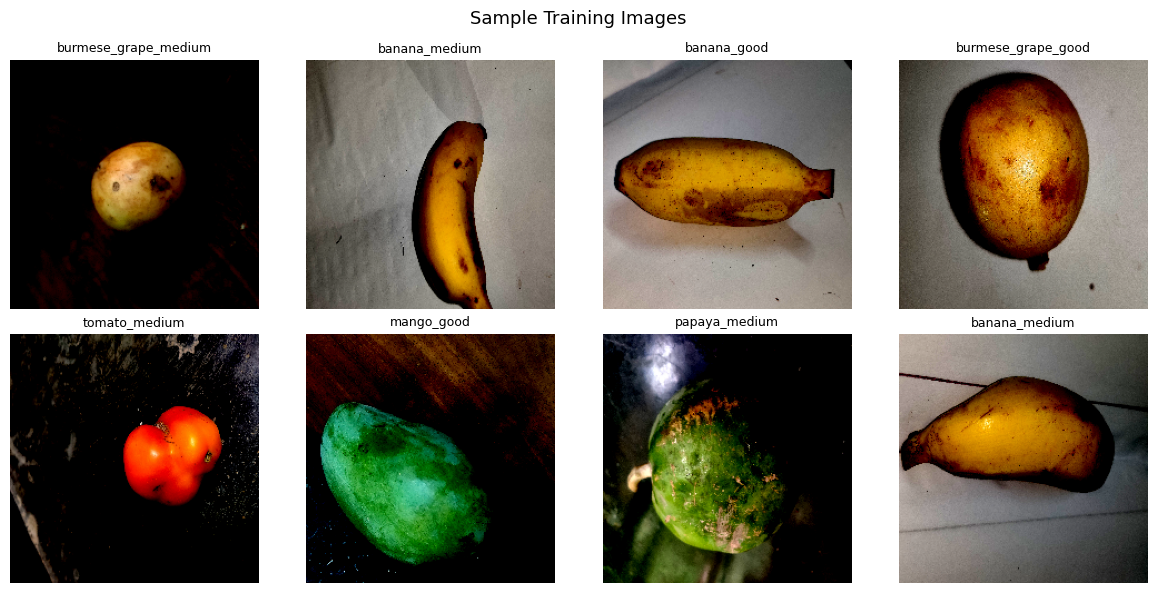

In [5]:
# Visualize sample images from the training dataset
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X_train):
        ax.imshow(X_train[i])
        ax.set_title(cate[Y_train[i]], fontsize=9)
        ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

## 4. MobileNetV2 Model Architecture
Transfer-learning pipeline using **MobileNetV2** (pre-trained on ImageNet) as the backbone,
matching the classifier used in the [fruit-quality-detector](https://github.com/VishStack01/fruit-quality-detector) repository.

**Training strategy:**
1. **Phase 1 — Feature extraction**: Freeze the MobileNetV2 backbone and train only the custom head.
2. **Phase 2 — Fine-tuning**: Unfreeze the top layers of the backbone and continue training at a lower learning rate.

The Grad-CAM helper in the repo targets the `mobilenetv2_1.00_224` layer, confirming this exact backbone.

In [6]:
num_classes = len(cate)

# ── MobileNetV2 backbone (fruit-quality-detector uses 'mobilenetv2_1.00_224') ──
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,          # remove ImageNet classification head
    weights='imagenet',         # pretrained ImageNet weights
    name='mobilenetv2_1.00_224' # must match Grad-CAM layer name in the repo
)
base_model.trainable = False    # Phase 1: freeze backbone

# ── Custom classification head (matches repo architecture) ──
inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)          # global spatial average pooling
x = BatchNormalization()(x)              # stabilise activations
x = Dense(256, activation='relu')(x)    # dense layer 1
x = Dropout(0.4)(x)                     # regularisation
x = Dense(128, activation='relu')(x)    # dense layer 2
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)  # output probabilities

model = Model(inputs, outputs, name='MobileNetV2_FruitQuality')
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_FruitQuality"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,258 (10.02 MB)

 Trainable params: 365,714 (1.40 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [7]:
# ── Phase 1: Train only the custom head (backbone frozen) ──
print("[Phase 1] Training classification head with frozen MobileNetV2 backbone...")

adam_phase1 = Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=adam_phase1,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_phase1 = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history_phase1 = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop_phase1]
)

print(f"[Phase 1] Best val_accuracy: {max(history_phase1.history['val_accuracy']):.4f}")

# ── Phase 2: Fine-tune top layers of MobileNetV2 backbone ──
print("\n[Phase 2] Fine-tuning top layers of MobileNetV2 backbone...")

base_model.trainable = True

# Unfreeze only the top-most ~30 layers (same approach as repo)
FINE_TUNE_FROM = max(0, len(base_model.layers) - 30)
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

print(f"Fine-tuning {len(base_model.layers) - FINE_TUNE_FROM} layers (out of {len(base_model.layers)})")

# Use a much lower learning rate for fine-tuning to avoid destroying pretrained features
adam_phase2 = Adam(learning_rate=LEARNING_RATE / 10.0)
model.compile(
    optimizer=adam_phase2,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_phase2 = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history_phase2 = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop_phase2]
)

print(f"[Phase 2] Best val_accuracy: {max(history_phase2.history['val_accuracy']):.4f}")

# Merge histories for plotting downstream
import copy
history = copy.deepcopy(history_phase2)
for k in history.history:
    history.history[k] = history_phase1.history[k] + history_phase2.history[k]

[Phase 1] Training classification head with frozen MobileNetV2 backbone...
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 538ms/step - accuracy: 0.5844 - loss: 1.3415 - val_accuracy: 0.8205 - val_loss: 0.6141
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7710 - loss: 0.6552 - val_accuracy: 0.8107 - val_loss: 0.4988
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8119 - loss: 0.5124 - val_accuracy: 0.8540 - val_loss: 0.3984
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8411 - loss: 0.4360 - val_accuracy: 0.8679 - val_loss: 0.3409
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8534 - loss: 0.3760 - val_accuracy: 0.8738 - val_loss: 0.3225
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8578 - loss: 0.3238 - val_accuracy: 0.8876 - val_loss: 0.3183
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8731 - loss: 0.3285 - val_accuracy: 0.8639 - val_loss: 0.3553
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━

## 5. Training History & Model Evaluation

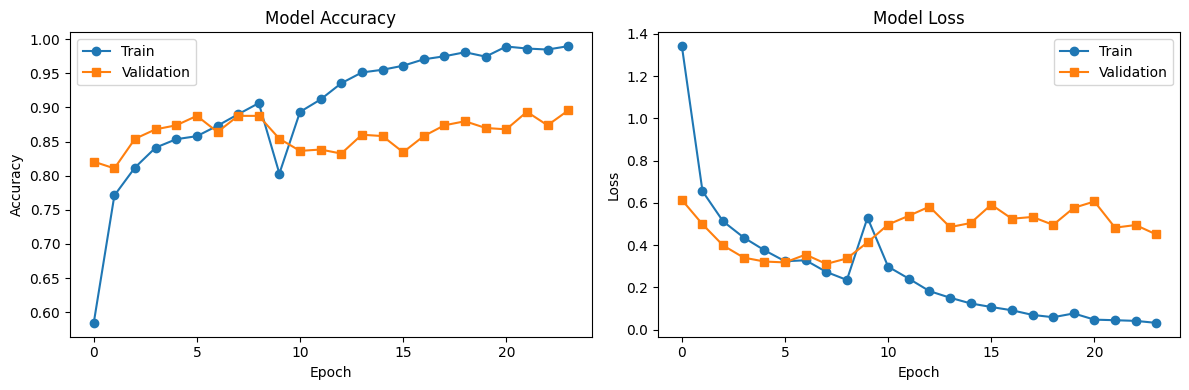

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 716ms/step
Classification Report:
                      precision    recall  f1-score   support

           apple_bad       0.95      0.95      0.95        22
          apple_good       0.77      1.00      0.87        40
        apple_medium       0.96      0.66      0.78        35
          banana_bad       0.00      0.00      0.00         0
         banana_good       0.90      0.90      0.90        49
       banana_medium       0.90      0.90      0.90        48
   burmese_grape_bad       0.97      0.88      0.92        33
  burmese_grape_good       0.93      0.87      0.90        62
burmese_grape_medium       0.69      0.84      0.76        32
           mango_bad       1.00      0.87      0.93        23
          mango_good       0.90      0.88      0.89        50
        mango_medium       0.82      0.92      0.87        50
          papaya_bad       1.00      1.00      1.00        31
         papaya_good       0.81      0.97      0.88        30
    

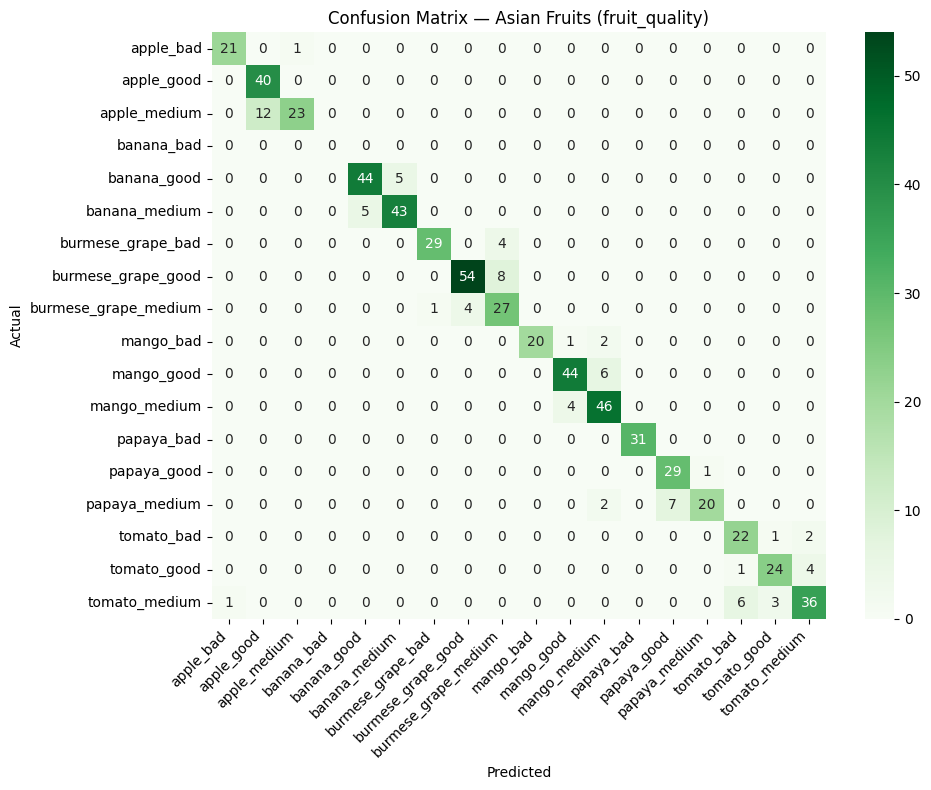

In [9]:
pred = model.predict(X_test)
pred_cat = pred.argmax(axis=1)

print("Classification Report:")
print(classification_report(
    Y_test,
    pred_cat,
    labels=range(len(cate)),
    target_names=cate,
    zero_division=0
))

tab = confusion_matrix(Y_test, pred_cat, labels=range(len(cate)))
plt.figure(figsize=(10, 8))
sns.heatmap(tab, annot=True, fmt='d', xticklabels=cate, yticklabels=cate, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — Asian Fruits ({TASK_MODE})')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


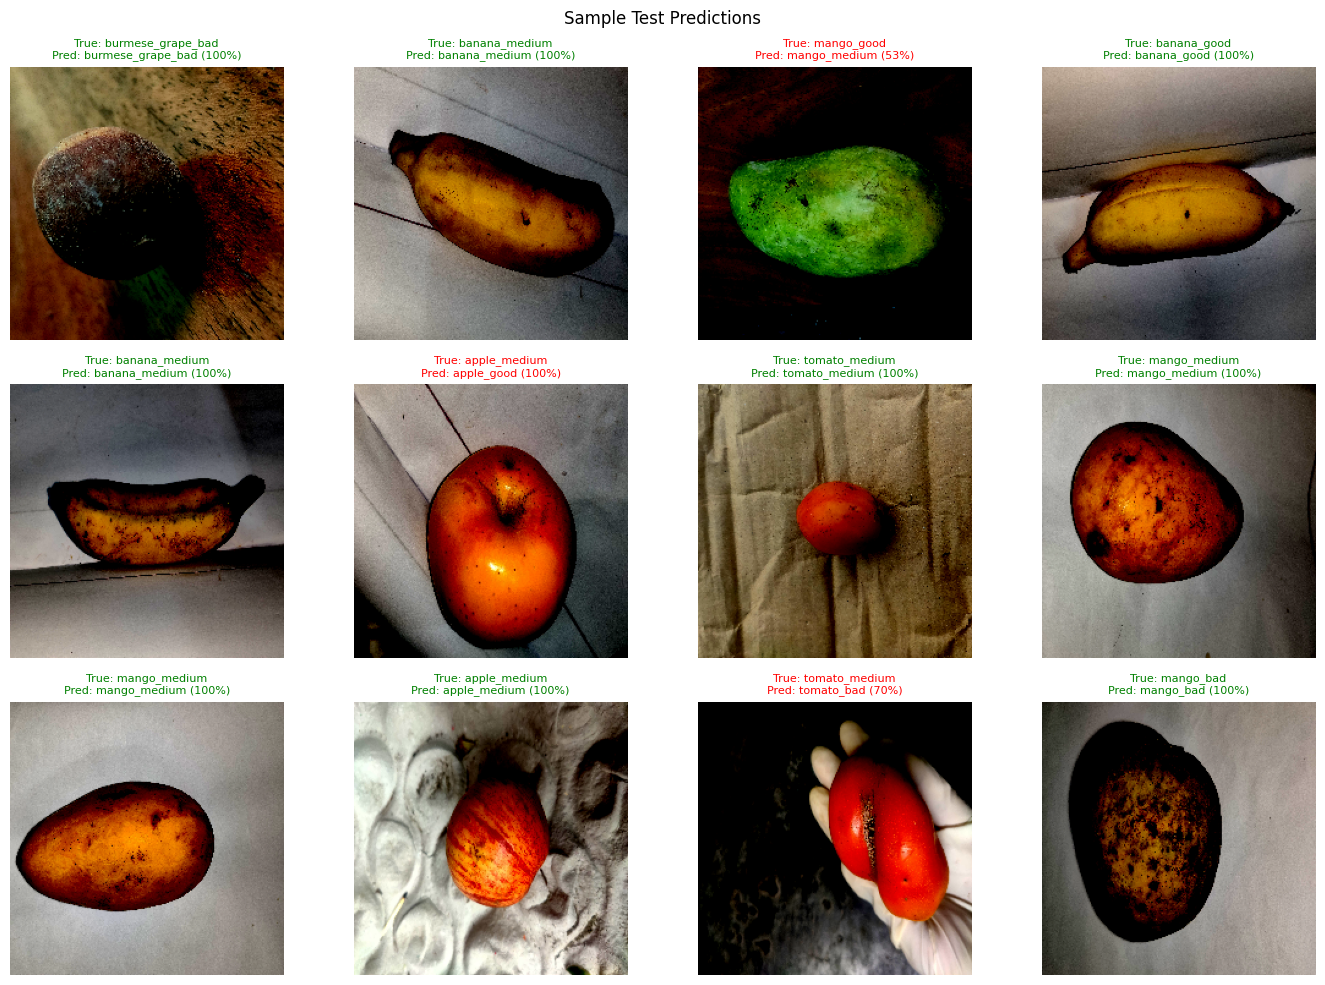

In [10]:
pred_all = model.predict(X_test, verbose=0)
num_samples = min(12, len(X_test))
indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in zip(indices, axes.flat):
    img = X_test[i]
    true_label = cate[Y_test[i]]
    pred_label = cate[np.argmax(pred_all[i])]
    confidence = np.max(pred_all[i]) * 100

    ax.imshow(img)
    ax.axis('off')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)", color=color, fontsize=8)

plt.suptitle('Sample Test Predictions', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Save Model Checkpoints

In [11]:
model.save('fruit_quality_model.keras')
print("[INFO] Saved: fruit_quality_model.keras")

model.save('fruit_quality_model.h5')
print("[INFO] Saved: fruit_quality_model.h5")

model.save('fruit_quality_deploy.keras', include_optimizer=False)
print("[INFO] Saved: fruit_quality_deploy.keras (deployment optimized)")

[INFO] Saved: fruit_quality_model.keras
[INFO] Saved: fruit_quality_model.h5
[INFO] Saved: fruit_quality_deploy.keras (deployment optimized)


## 7. Single Image Prediction Function
Inference helper to grade any given input image.

Prediction: apple_bad | Confidence: 42.07%
Per-class probabilities:
  apple_bad                     : 42.07%
  apple_good                    : 0.20%
  apple_medium                  : 39.92%
  banana_bad                    : 0.00%
  banana_good                   : 0.00%
  banana_medium                 : 0.00%
  burmese_grape_bad             : 0.18%
  burmese_grape_good            : 0.01%
  burmese_grape_medium          : 16.78%
  mango_bad                     : 0.00%
  mango_good                    : 0.01%
  mango_medium                  : 0.03%
  papaya_bad                    : 0.01%
  papaya_good                   : 0.27%
  papaya_medium                 : 0.11%
  tomato_bad                    : 0.01%
  tomato_good                   : 0.01%
  tomato_medium                 : 0.38%


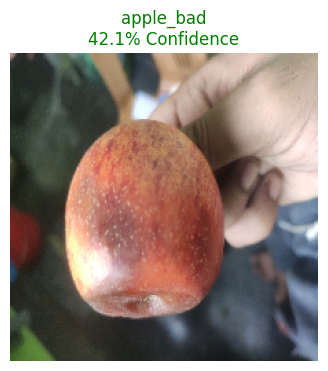

In [12]:
def predict_single_image(image_path_or_array, model, categories, image_size=224, show_plot=True):
    """Predicts the fruit variety and quality grade for a given image.
    Uses MobileNetV2 preprocessing (pixels scaled to [-1, 1]) to match training.
    """
    if isinstance(image_path_or_array, str):
        img_bgr = cv2.imread(image_path_or_array)
        if img_bgr is None:
            raise FileNotFoundError(f"Could not load image: {image_path_or_array}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = image_path_or_array
        # If already float in [-1, 1] (preprocessed), reverse for display
        if img_rgb.dtype in [np.float32, np.float64] and img_rgb.min() < 0:
            img_rgb = ((img_rgb + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)

    img_resized = cv2.resize(img_rgb.astype(np.uint8), (image_size, image_size))

    # Apply MobileNetV2 preprocessing: scales pixels to [-1, 1]
    img_preprocessed = mobilenet_preprocess(img_resized.astype(np.float32))
    img_input = np.expand_dims(img_preprocessed, axis=0)

    preds = model.predict(img_input, verbose=0)[0]
    best_idx = np.argmax(preds)
    pred_label = categories[best_idx]
    confidence = preds[best_idx] * 100.0

    print(f"Prediction: {pred_label} | Confidence: {confidence:.2f}%")
    print("Per-class probabilities:")
    for cat, prob in zip(categories, preds):
        print(f"  {cat:30s}: {prob*100:.2f}%")

    if show_plot:
        plt.figure(figsize=(4, 4))
        plt.imshow(img_resized)
        plt.axis('off')
        plt.title(f"{pred_label}\n{confidence:.1f}% Confidence", color="green", fontsize=12)
        plt.show()

    return pred_label, confidence

# Example test on first test image (reverse-preprocess for display):
if 'X_test' in locals() and len(X_test) > 0:
    predict_single_image(X_test[0], model, cate)